In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
cd "/content/drive/MyDrive/meta_data"

/content/drive/MyDrive/meta_data


In [9]:
!pip install category_encoders

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder, OneHotEncoder
from category_encoders import BinaryEncoder # BinaryEncoder for binary categorical features
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [11]:
# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

In [12]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [13]:
# 2. INITIAL EXPLORATION & CLEANING
# Initial data inspection
print("=== Initial Data Summary ===")
print(f"Records: {len(df)}")
print(f"Columns: {len(df.columns)}")
print("\nMissing values per column:")
print(df.isnull().sum())

=== Initial Data Summary ===
Records: 180519
Columns: 53

Missing values per column:
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                           

In [14]:
# Remove unnecessary columns
cols_to_drop = [
    'Product Description', 'Product Image', 'Customer Password', 'Customer Email',
    'Customer Fname', 'Customer Lname', 'Order Zipcode', 'Latitude', 'Longitude'
]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [15]:
# Remove duplicate helper columns after validation
# Ensure columns are identical
if (df['Customer Id'] == df['Order Customer Id']).all():
    df = df.drop(columns=['Order Customer Id'])
if (df['Product Card Id'] == df['Order Item Cardprod Id']).all():
    df = df.drop(columns=['Order Item Cardprod Id'])

# Remove spaces from column names and fix common issues
df.columns = df.columns.str.replace(' ', '')
df = df.rename(columns={
    'Daysforshipping(real)': 'DaysForShippingReal','Daysforshipment(scheduled)' : 'DaysForShipmentScheduled'
})

In [16]:
# 3. HANDLE MISSING VALUES
# -----------------------------

# Fill missing CustomerZipcode with string "0.0"
df['CustomerZipcode'] = df['CustomerZipcode'].fillna('0.0')

In [17]:
# change to datetime format
df['orderdate(DateOrders)'] = pd.to_datetime(df['orderdate(DateOrders)'])
df['shippingdate(DateOrders)'] = pd.to_datetime(df['shippingdate(DateOrders)'])

In [18]:
# 5. ROUND NUMERIC COLUMNS
# -----------------------------

two_decimals = [
    'Benefitperorder', 'OrderItemDiscount', 'OrderItemProductPrice',
    'Sales', 'OrderItemTotal', 'OrderProfitPerOrder', 'ProductPrice'
]
six_decimals = [
    'OrderItemDiscountRate', 'OrderItemProfitRatio',
]

# Round
df[two_decimals] = df[two_decimals].round(2)
df[six_decimals] = df[six_decimals].round(6)

In [19]:
# @title Feature Engineering


In [20]:
# 1. Shipping buffer time (negative = delay)
#df['ShippingBuffer'] = df['DaysForShipmentScheduled'] - df['DaysForShippingReal']

# 2. Peak season flag (holidays often cause delays)
order_month = df['orderdate(DateOrders)'].dt.month
df['PeakSeason'] = order_month.isin([11, 12]).astype(int)  # Nov-Dec

# 3. Day of week (weekends may cause delays)
df['order_dayofweek'] = df['orderdate(DateOrders)'].dt.dayofweek

# 4. Avg delivery time per product category (target encoding)
category_avg_delay = df.groupby('CategoryName')['Late_delivery_risk'].mean().to_dict()
df['category_risk'] = df['CategoryName'].map(category_avg_delay)

# 5. Capacity overload (many orders same day)
# Convert datetime to date only (year-month-day)
df['order_date_only'] = df['orderdate(DateOrders)'].dt.date
# Count orders per day
daily_orders = df.groupby('order_date_only')['OrderId'].count().to_dict()
# Map the daily order count to the original dataframe
df['daily_order_volume'] = df['order_date_only'].map(daily_orders)

In [21]:
pd.set_option('display.max_columns', None)

In [22]:
num_features = ['DaysForShipmentScheduled', 'order_dayofweek', 'category_risk', 'daily_order_volume']
cat_features = ['ShippingMode', 'OrderRegion', 'Market', 'CustomerCity']
bool_features = ['PeakSeason']
target_features = ['Late_delivery_risk']

df_final = df[num_features+cat_features+bool_features+target_features]

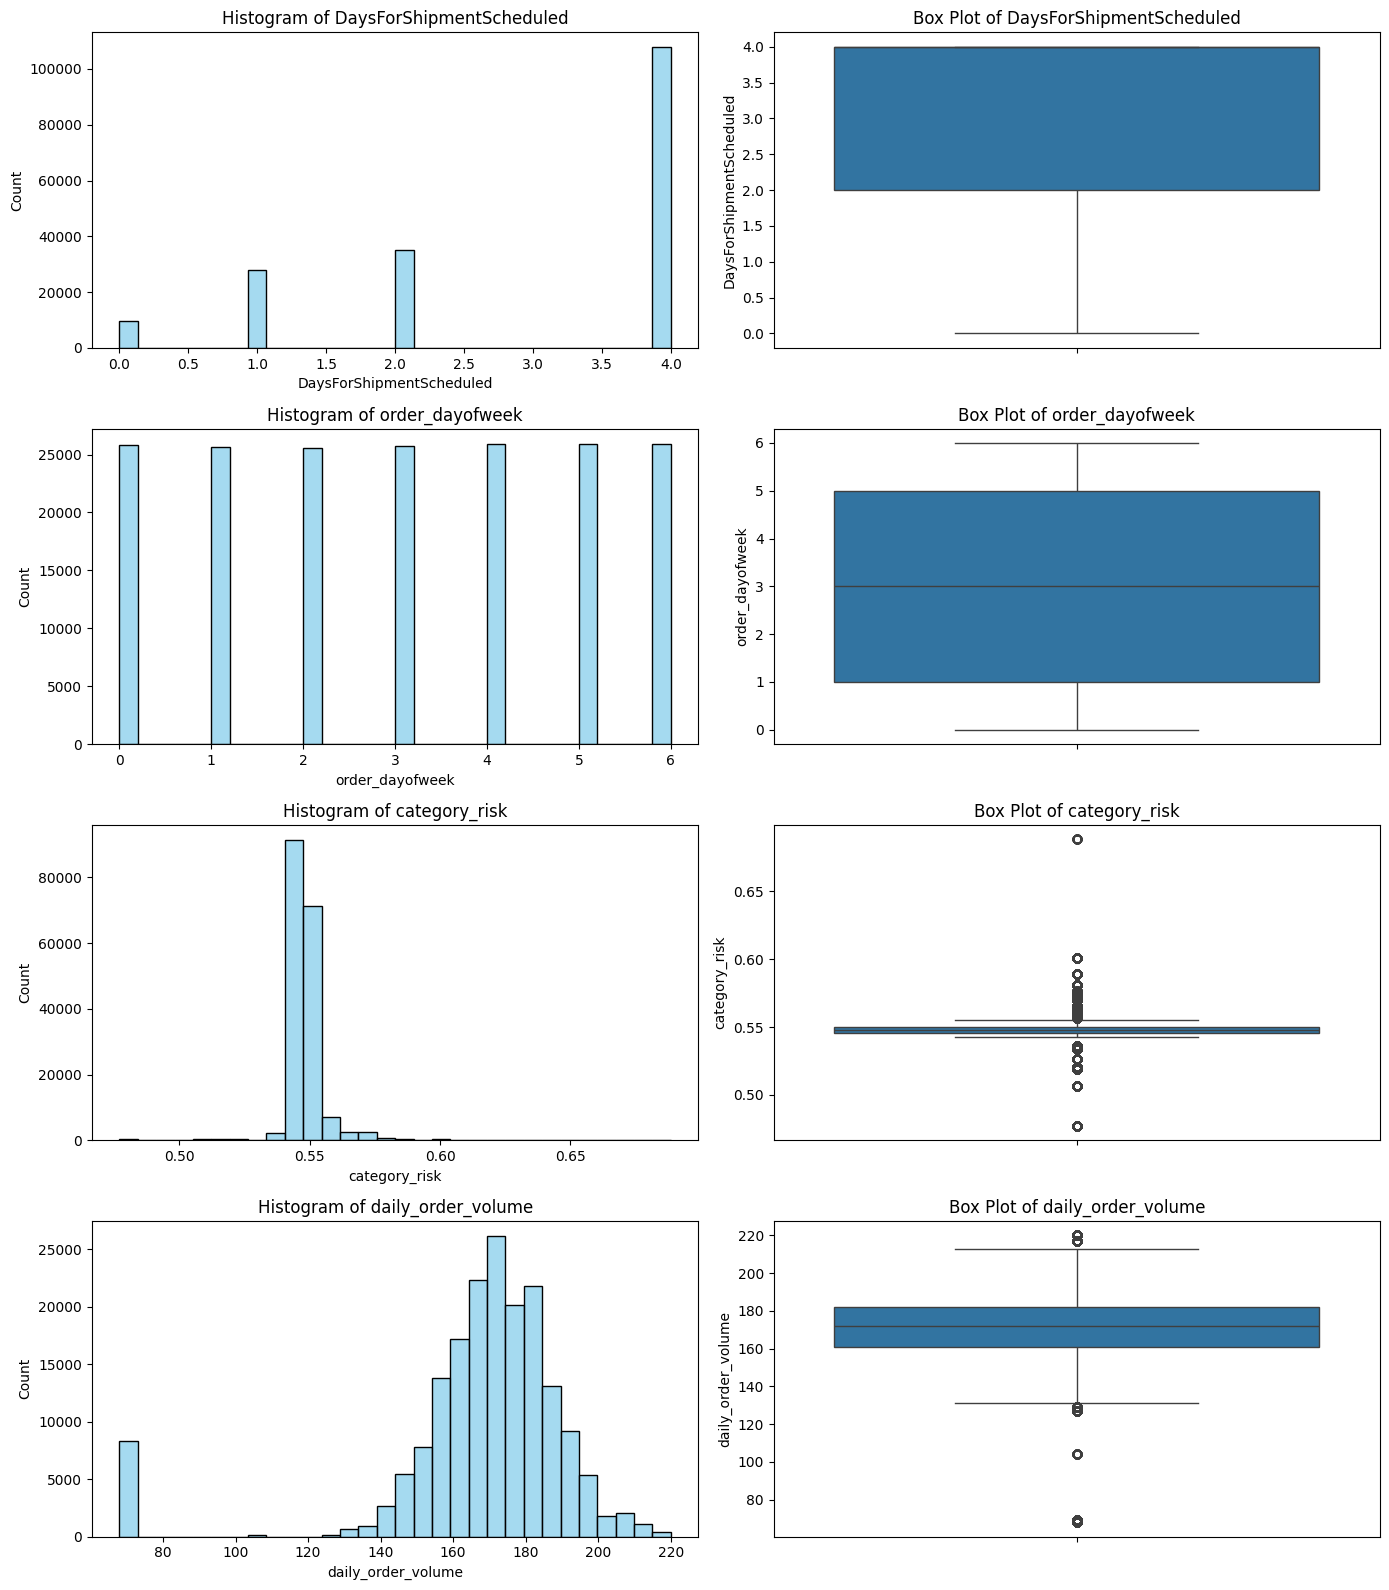

In [23]:
# @title Outlier detection

# Plotting histograms and boxplots
# Calculate the figure layout based on the number of columns
def Visualize_box_hist(df, n_cols, n_rows, num_clos):

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))

    # Loop through each numerical column and plot both histogram and boxplot
    for i, column in enumerate(num_clos):
        # Plot histogram on the left
        sns.histplot(df[column], bins=30, color='skyblue', ax=axes[i, 0])
        axes[i, 0].set_title(f'Histogram of {column}')

        # Plot boxplot on the right
        sns.boxplot(y=df[column], ax=axes[i, 1])
        axes[i, 1].set_title(f'Box Plot of {column}')

    # Adjust layout for better readability
    plt.tight_layout()
    plt.show()

n_cols = 2  # Number of columns per row
n_rows = len(num_features)  # Calculate required rows
Visualize_box_hist(df_final, n_cols, n_rows, num_features)

from above visualisation we can find that only category_risk and daily_order_volume has outliers. So we deal with these features only.

To deal we will perform capping method, because Both category_risk and daily_order_volume have most of their values clustered in a narrow band. There are only a handful of points far outside that band. Capping directly “pins” those extremes at the threshold without warping the bulk of the data.

/tmp/ipython-input-24-809882300.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[129.5 129.5 129.5 ... 158.  158.  158. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_out.loc[:, col] = df_out[col].clip(lower=lower, upper=upper)


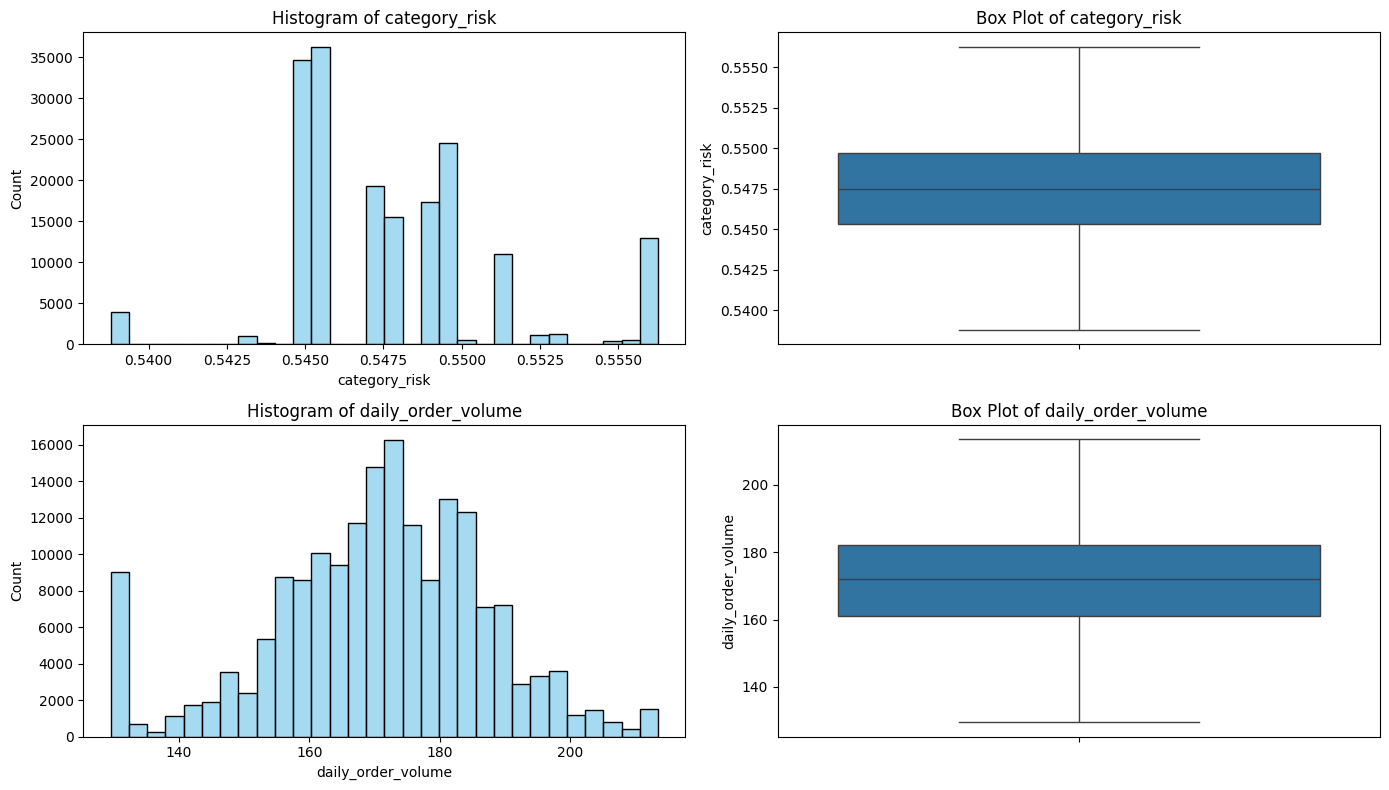

In [24]:
def capping_outliers(df_out, features):
  for col in features:
    # 1) Compute IQR bounds
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    # 2) Cap outliers to the IQR bounds
    df_out.loc[:, col] = df_out[col].clip(lower=lower, upper=upper)

  return df_out

# now perform caaping outliers
deal_features = ['category_risk', 'daily_order_volume']
df_final= capping_outliers(df_final, deal_features)

# visualization after dealing with outliers
Visualize_box_hist(df_final, n_cols, len(deal_features), deal_features)

In [25]:
df_final.head()

,DaysForShipmentScheduled,order_dayofweek,category_risk,daily_order_volume,ShippingMode,OrderRegion,Market,CustomerCity,PeakSeason,Late_delivery_risk
0,4,2,0.554622,129.5,Standard Class,Southeast Asia,Pacific Asia,Caguas,0,0
1,4,5,0.554622,129.5,Standard Class,South Asia,Pacific Asia,Caguas,0,1
2,4,5,0.554622,129.5,Standard Class,South Asia,Pacific Asia,San Jose,0,0
3,4,5,0.554622,129.5,Standard Class,Oceania,Pacific Asia,Los Angeles,0,0
4,4,5,0.554622,129.5,Standard Class,Oceania,Pacific Asia,Caguas,0,0


### Feature Scaling

### Deal with Numerical Features

First we visualize wheather all features are normally distributed. If they are normally distributed, then we perform Standardization otherwise we will perform Normalization.

Standardize features close to normal distributions. Skewness is close to 0 (between -0.5 and 0.5), and kurtosis is also within a reasonable range (typically between -1 and +1)

Normalize features with higher skewness and kurtosis extremes. Features with higher skewness (|skewness| > 0.5) and/or more extreme kurtosis values (kurtosis less than -1.5 or greater than 1.5)

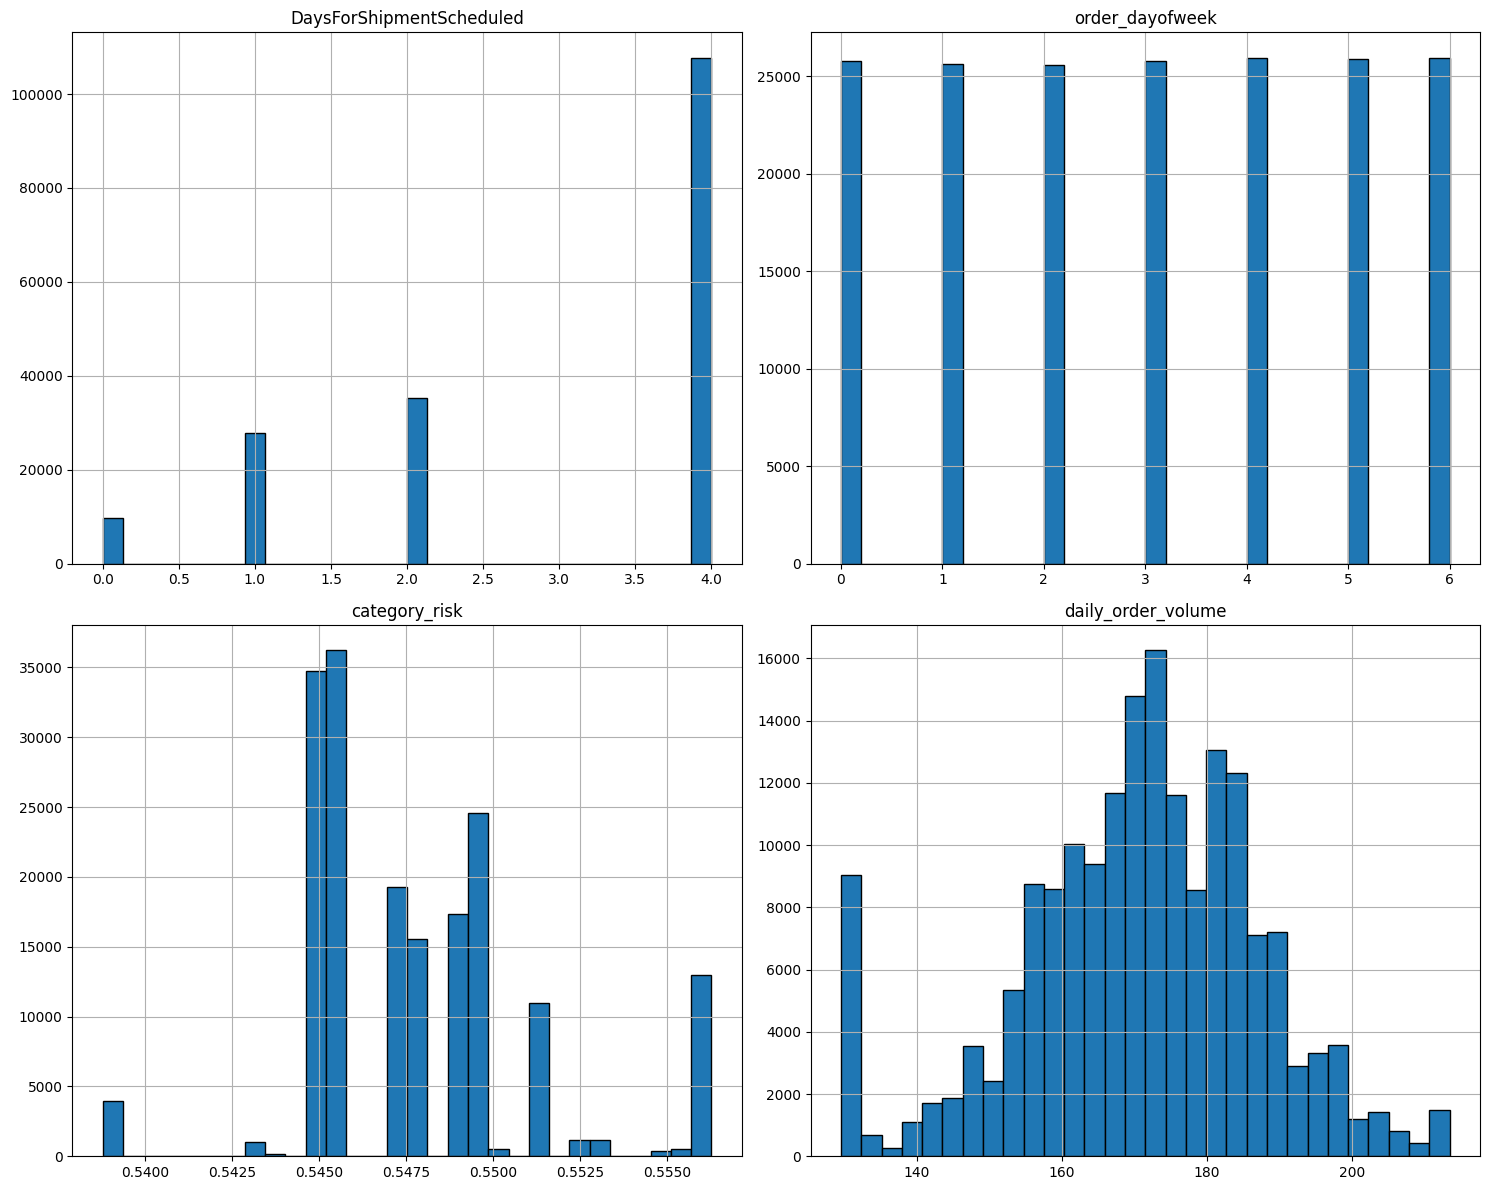

In [26]:
# plot histograms
df_final[num_features].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

In [27]:
# Check Skewness and Kurtosis
for column in num_features:
    skewness = df_final[column].skew()
    kurtosis = df_final[column].kurtosis()
    print(f"{column} - Skewness: {skewness}, Kurtosis: {kurtosis}")

DaysForShipmentScheduled - Skewness: -0.7319982842174512, Kurtosis: -1.022948807002554
order_dayofweek - Skewness: -0.0066650373370776604, Kurtosis: -1.2513154595076643
category_risk - Skewness: 0.6010060673987747, Kurtosis: 0.9795669840852184
daily_order_volume - Skewness: -0.40820184326883696, Kurtosis: 0.32792524688612845


From above Histogram and by checking Skewness and Kurtosis, We can conclude that we should perform standarization for daily_order_volume, order_dayofweek and NOrmalization for DaysForShipmentScheduled, category_risk.

For Standarization we will perform StandardScaler and for Normalization we perform MinMaxScaler.

StandardScaler → can produce negative (<0) and >1 values (z‑scores).

MinMaxScaler → forces everything into the [0, 1] interval.

In [28]:
norm_features = ['DaysForShipmentScheduled', 'category_risk']
stand_features = ['order_dayofweek', 'daily_order_volume']

### Categorical Features

*CustomerCity* has many unique cities, One-Hot Encoding will create too many columns. So We perform Binary Encoding for CustomerCity.

In [29]:
# Frequency encode
#df_final = df_final.copy()
#df_final['CustomerCity_freq'] = df_final['CustomerCity'].map(df_final['CustomerCity'].value_counts(normalize=True))

# Drop the original column
#df_final.drop(columns=['CustomerCity'], inplace=True)

In [30]:
# Categorical Feature Groups
ordinal_features = ['ShippingMode']
ordinal_categories = [['Standard Class', 'Second Class', 'First Class', 'Same Day']]

onehot_features = ['OrderRegion', 'Market']

hc_cat = ['CustomerCity']

### Pipeline for Scaling and Encoding

We use Pipeline as we are working with multiple encoding techniques. It allows us to organize our preprocessing steps systematically and ensure consistency across both training and prediction phases.

In [31]:
# ColumnTransformer for separate scaling
preprocessor = ColumnTransformer(transformers=[
    ('norm', MinMaxScaler(), norm_features),
    ('std',  StandardScaler(), stand_features),
    ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features),
    ('ohe', OneHotEncoder(handle_unknown='ignore'), onehot_features),
    ('binary', BinaryEncoder(), hc_cat)
], remainder='passthrough') # Keep the other columns (if any) as it is

In [32]:
# Full pipeline
pipeline = Pipeline(steps=[
    ('preprocess', preprocessor)
])

# Fit and transform
preprocessed_data = pipeline.fit_transform(df_final)

In [33]:
# Recover the output feature names
feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
column_names = [name.split('__', 1)[1] if '__' in name else name
    for name in feature_names]
column_names

['DaysForShipmentScheduled',
 'category_risk',
 'order_dayofweek',
 'daily_order_volume',
 'ShippingMode',
 'OrderRegion_Canada',
 'OrderRegion_Caribbean',
 'OrderRegion_Central Africa',
 'OrderRegion_Central America',
 'OrderRegion_Central Asia',
 'OrderRegion_East Africa',
 'OrderRegion_East of USA',
 'OrderRegion_Eastern Asia',
 'OrderRegion_Eastern Europe',
 'OrderRegion_North Africa',
 'OrderRegion_Northern Europe',
 'OrderRegion_Oceania',
 'OrderRegion_South America',
 'OrderRegion_South Asia',
 'OrderRegion_South of  USA ',
 'OrderRegion_Southeast Asia',
 'OrderRegion_Southern Africa',
 'OrderRegion_Southern Europe',
 'OrderRegion_US Center ',
 'OrderRegion_West Africa',
 'OrderRegion_West Asia',
 'OrderRegion_West of USA ',
 'OrderRegion_Western Europe',
 'Market_Africa',
 'Market_Europe',
 'Market_LATAM',
 'Market_Pacific Asia',
 'Market_USCA',
 'CustomerCity_0',
 'CustomerCity_1',
 'CustomerCity_2',
 'CustomerCity_3',
 'CustomerCity_4',
 'CustomerCity_5',
 'CustomerCity_6',
 

In [34]:
# Build a DataFrame
df_transformed = pd.DataFrame(
    preprocessed_data,
    columns=column_names,
    index=df_final.index
)

df_transformed.head(5)

,DaysForShipmentScheduled,category_risk,order_dayofweek,daily_order_volume,ShippingMode,OrderRegion_Canada,OrderRegion_Caribbean,OrderRegion_Central Africa,OrderRegion_Central America,OrderRegion_Central Asia,OrderRegion_East Africa,OrderRegion_East of USA,OrderRegion_Eastern Asia,OrderRegion_Eastern Europe,OrderRegion_North Africa,OrderRegion_Northern Europe,OrderRegion_Oceania,OrderRegion_South America,OrderRegion_South Asia,OrderRegion_South of USA,OrderRegion_Southeast Asia,OrderRegion_Southern Africa,OrderRegion_Southern Europe,OrderRegion_US Center,OrderRegion_West Africa,OrderRegion_West Asia,OrderRegion_West of USA,OrderRegion_Western Europe,Market_Africa,Market_Europe,Market_LATAM,Market_Pacific Asia,Market_USCA,CustomerCity_0,CustomerCity_1,CustomerCity_2,CustomerCity_3,CustomerCity_4,CustomerCity_5,CustomerCity_6,CustomerCity_7,CustomerCity_8,CustomerCity_9,PeakSeason,Late_delivery_risk
0,1.0,0.90578,-0.503426,-2.433968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.90578,0.995427,-2.433968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,1.0,0.90578,0.995427,-2.433968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.90578,0.995427,-2.433968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,1.0,0.90578,0.995427,-2.433968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


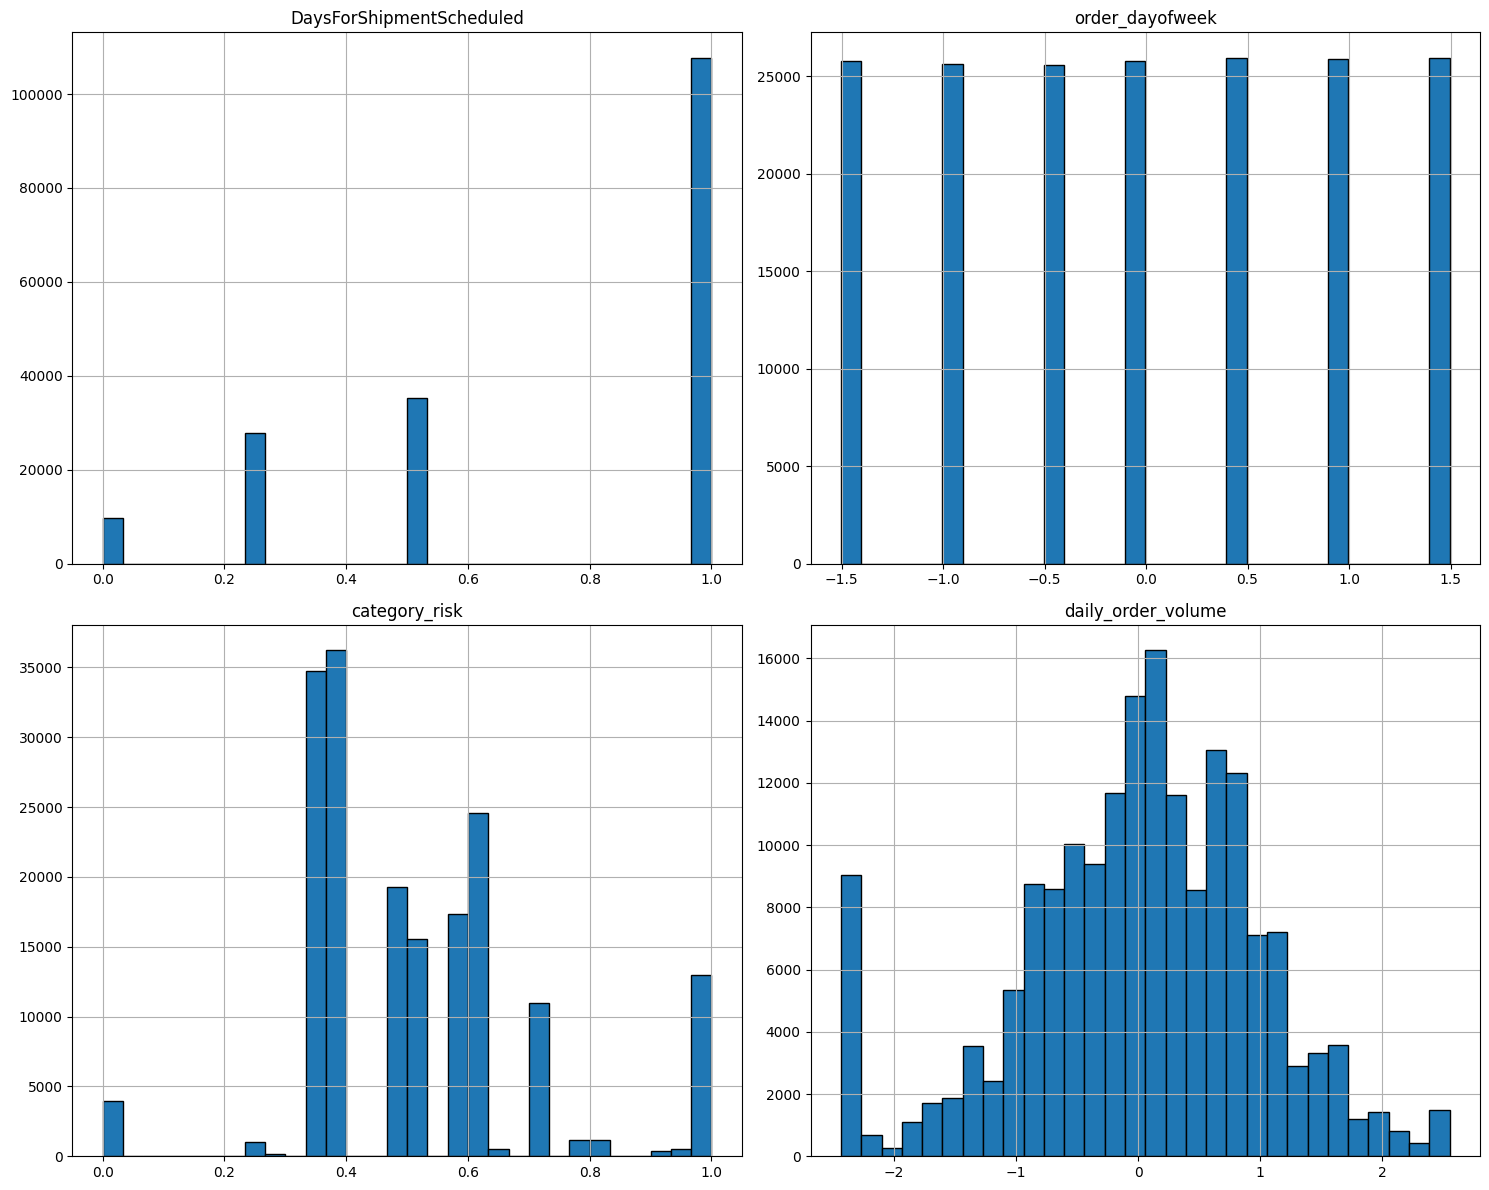

In [35]:
# plot histograms after Scaling

# Convert the numerical columns to float
df_transformed[num_features] = df_transformed[num_features].astype(float)

df_transformed[num_features].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

Save preprocessed dataset

In [36]:
df_transformed.to_pickle('preprocessed_data.pkl')

In [37]:
df_prep = pd.read_pickle('preprocessed_data.pkl')

df_prep.dtypes

,0
DaysForShipmentScheduled,float64
category_risk,float64
order_dayofweek,float64
daily_order_volume,float64
ShippingMode,float64
OrderRegion_Canada,float64
OrderRegion_Caribbean,float64
OrderRegion_Central Africa,float64
OrderRegion_Central America,float64
OrderRegion_Central Asia,float64
